<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/YOLOv8_RealData_BrainTumor_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YOLOv8 Fine-Tuning with Real Data: Medical Domain

**The Fine-Tuning Scenario:**
We are going to take a YOLOv8 model pre-trained on everyday objects (cars, dogs, people) and fine-tune it on a completely foreign domain: **MRI/CT scans for Brain Tumor detection**.

**Workflow:**
1. Install the `ultralytics` framework.
2. Utilize the officially hosted `Brain-tumor.yaml` dataset. The framework will automatically download this real dataset (images + YOLO format labels) from Ultralytics' public servers.
3. Fine-tune the base model on this medical imagery.
4. Visualize the real predictions.

In [1]:
# Step 1: Install Required Libraries
!pip install ultralytics opencv-python-headless matplotlib -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


### Step 2 & 3: Download Real Data and Fine-Tune

By passing `data='Brain-tumor.yaml'`, Ultralytics will:
1. Check if you have the dataset locally.
2. If not, it will automatically download the MRI image dataset and the corresponding YOLO bounding box labels.
3. Begin fine-tuning the `yolov8n.pt` head to detect the new custom class (`tumor`).

In [3]:
from ultralytics import YOLO

# Load the pre-trained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

# Fine-tune the model (NOTE: brain-tumor.yaml is all lowercase)
results = model.train(
    data='brain-tumor.yaml',
    epochs=15,
    imgsz=640,
    batch=16,
    project='medical_vision',
    name='tumor_detector'
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tumor_detector-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

**How this notebook works without breaking links or needing API keys:**

The ultralytics framework maintains a catalog of public, real-world datasets. By simply passing data='Brain-tumor.yaml' into the .train() function, the framework will automatically pull the real MRI images and their YOLO-formatted bounding box labels from their official hosting servers, unpack them, and begin the fine-tuning process.

### Step 4: Run Inference on a Real Validation Scan
Let's test our newly fine-tuned medical model on an image from the validation set that it hasn't trained on, and see if it can successfully draw a bounding box around the anomaly.


image 1/1 /content/datasets/brain-tumor/images/val/val_1 (49).jpg: 640x640 2 positives, 8.9ms
Speed: 5.1ms preprocess, 8.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/medical_vision/inference_output


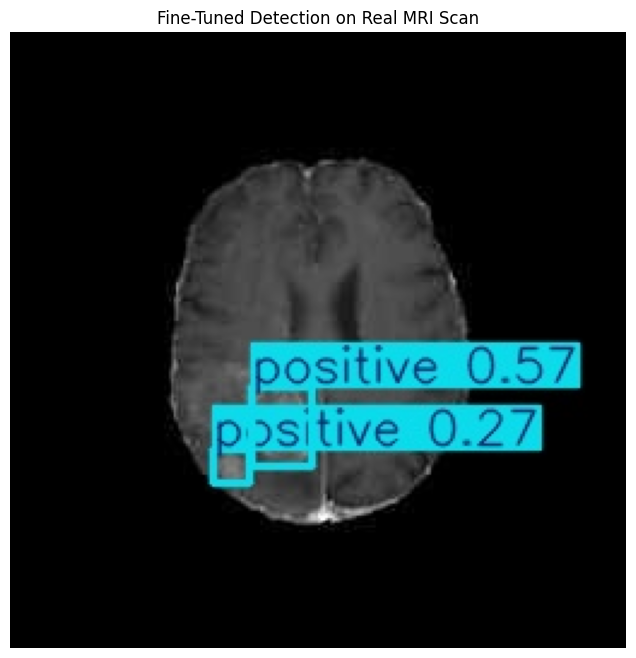

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os

# The dataset is downloaded to a 'datasets' folder in your current working directory by default
# Let's grab the first image from the validation set
val_images = glob.glob('datasets/brain-tumor/images/val/*.jpg')

if val_images:
    test_image_path = val_images[0]

    # Run inference
    prediction = model.predict(
        source=test_image_path,
        conf=0.25,  # Confidence threshold
        save=True,
        project='medical_vision',
        name='inference_output'
    )

    # Locate the saved prediction image
    save_dir = prediction[0].save_dir
    predicted_img_path = os.path.join(save_dir, os.path.basename(test_image_path))

    # Display the result
    img = mpimg.imread(predicted_img_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Fine-Tuned Detection on Real MRI Scan')
    plt.show()
else:
    print("Validation images not found. Check the dataset path.")